# **Notebook : Single-Cell Pipeline – Normalization, Dimensionality Reduction & Clustering**

This notebook processes the filtered single-nucleus dataset (`adata_filtered.h5ad`) prepared in `reduction_of_dataset.ipynb`.

It performs normalization, log-transformation, HVG selection, PCA, UMAP, Leiden clustering and marker identification.

The processed object (`adata_pp.h5ad`) will be used for cluster annotation and pseudobulk differential expression (in `translation_to_R.ipynb`).

---

**Pipeline Overview:**
- Setup and Configuration
- Data Preparation (Normalization, HVG, Scaling)
- Dimensionality Reduction (PCA, UMAP, Leiden)
- Quality Checks
- Marker Gene Identification
- Save Processed Object

**Note:** This pipeline does NOT perform batch correction or integration. The AD/PD/CTRL cohort is too small for reliable integration, particularly for PD (only 3 donors).

# **Setup and Configuration**

### Environment Setup

Load required libraries and configure working directories for reproducible analysis.

In [1]:
import os
import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Set random seed for reproducibility
np.random.seed(42)

# PROJECT_ROOT = "/Users/elodiehusson/Desktop/AD & PD" # Elodie
# PROJECT_ROOT = "C:/Users/yarad/Desktop/x/Masters/Master BMC - Sorbonne/M2/Single Cell/Project/Coding Project" # Yara
PROJECT_ROOT = "C:/Z/AIDA_transcriptomics_project/transcriptomics-code"  # Laïla

# Define directory structure
DIRS = {
    "DATA":    os.path.join(PROJECT_ROOT, "data"),
    "FIGURES": os.path.join(PROJECT_ROOT, "figures", "single_cell_pipeline"),
    "EDA":     os.path.join(PROJECT_ROOT, "eda_results"),
    "TMP":     os.path.join(PROJECT_ROOT, "tmp_cache")
}

# Create directories if they don't exist
for path in DIRS.values():
    os.makedirs(path, exist_ok=True)

os.chdir(PROJECT_ROOT)

# Configure scanpy settings
sc.settings.figdir = DIRS["FIGURES"]
sc.settings.cachedir = DIRS["TMP"]
sc.settings.datasetdir = DIRS["DATA"]
sc.settings.set_figure_params(dpi=100, dpi_save=300, frameon=False, format='pdf')
sc.settings.verbosity = 2  # Show detailed progress

print(f"✅ Environment loaded. Working directory: {os.getcwd()}")
print(f"📁 Figures will be saved to: {DIRS['FIGURES']}")

✅ Environment loaded. Working directory: C:\Z\AIDA_transcriptomics_project\transcriptomics-code
📁 Figures will be saved to: C:/Z/AIDA_transcriptomics_project/transcriptomics-code\figures\single_cell_pipeline


### Load Filtered Dataset

Load the QC-filtered AnnData object from the previous notebook (`reduction_of_dataset.ipynb`).

In [2]:
# Load the filtered dataset (output from reduction_of_dataset.ipynb)
dataset_path = os.path.join(DIRS["DATA"], "adata_filtered.h5ad")
adata_filtered = sc.read_h5ad(dataset_path)

print(f"✅ Filtered dataset loaded.")
print(f"📊 Dataset dimensions: {adata_filtered.shape[0]:,} cells × {adata_filtered.shape[1]:,} genes")
print(f"\n🔍 Available metadata columns:")
print(adata_filtered.obs.columns.tolist())

✅ Filtered dataset loaded.
📊 Dataset dimensions: 62,800 cells × 34,176 genes

🔍 Available metadata columns:
['Source', 'n_genes', 'n_counts', 'class', 'subclass', 'subtype', 'tissue_ontology_term_id', 'tissue_type', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'donor_id', 'suspension_type', 'is_primary_data', 'AD_status', 'DLBD_status', 'FTD_status', 'Tauopathy_status', 'Vascular_status', 'ASCVD_status', 'Schizophrenia', 'Bipolar_Disorder', 'Parkinson_disease', 'Tardive_dyskinesia', 'genetic_ancestry', 'disease_ontology_term_id', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'simple_diagnosis']


# **Data Preparation (Normalization, HVG, Scaling)**

### Preprocessing Overview

This section performs the standard single-cell preprocessing workflow:

1. **Save raw counts**: Preserve original UMI counts in `adata.layers["counts"]` for downstream analyses (e.g., differential expression)
2. **Normalization**: Scale counts per cell to 10,000 total counts to account for sequencing depth differences
3. **Log-transformation**: Apply log1p to stabilize variance and reduce the impact of highly expressed genes
4. **Highly Variable Genes (HVG)**: Select 2,000 genes with highest variability across cells to focus on biological signal
5. **Scaling**: Z-score normalization to ensure genes contribute equally to downstream PCA

**Why these steps?**
- **HVG selection**: Reduces noise from lowly variable genes and computational burden while retaining biological information
- **Log-transformation**: Converts multiplicative differences to additive scale, making data more suitable for linear methods
- **Scaling**: Centers each gene to mean=0 and variance=1, preventing highly expressed genes from dominating PCA

In [3]:
# Save raw counts before any transformation
# CRITICAL: Never modify adata.layers["counts"] after this step
adata_filtered.layers["counts"] = adata_filtered.X.copy()
print("✅ Raw counts saved in adata.layers['counts']")

# Normalize total counts per cell to 10,000
# This accounts for differences in sequencing depth between cells
sc.pp.normalize_total(adata_filtered, target_sum=1e4)
print("✅ Normalization: total counts per cell scaled to 10,000")

# Log-transform the data: log(x + 1)
# This stabilizes variance and makes the data more normally distributed
sc.pp.log1p(adata_filtered)
print("✅ Log-transformation: log1p applied")

✅ Raw counts saved in adata.layers['counts']
normalizing counts per cell
    finished (0:00:01)
✅ Normalization: total counts per cell scaled to 10,000
✅ Log-transformation: log1p applied


In [4]:
# Identify highly variable genes (HVGs)
# Using Seurat v3 method which is robust for UMI data
# Select top 2,000 most variable genes and subset the dataset
sc.pp.highly_variable_genes(
    adata_filtered,
    n_top_genes=2000,
    subset=True,
    flavor='seurat_v3',
    batch_key=None  # No batch correction at this stage
)
print(f"✅ HVG selection: {adata_filtered.shape[1]} highly variable genes retained")
print(f"   Original gene count reduced from {adata_filtered.layers['counts'].shape[1]:,} to {adata_filtered.shape[1]:,}")

extracting highly variable genes
✅ HVG selection: 2000 highly variable genes retained
   Original gene count reduced from 2,000 to 2,000


In [5]:
# Scale data to unit variance and zero mean
# Clip values to maximum of 10 to prevent extreme outliers from dominating
sc.pp.scale(adata_filtered, max_value=10)
print("✅ Scaling: genes centered and scaled (max_value=10)")
print("\n📋 Preprocessing complete. Ready for dimensionality reduction.")

✅ Scaling: genes centered and scaled (max_value=10)

📋 Preprocessing complete. Ready for dimensionality reduction.


# **Dimensionality Reduction**

### PCA, Clustering & UMAP

This section performs:
1. **Principal Component Analysis (PCA)**: Linear dimensionality reduction to capture major sources of variation
2. **Neighborhood graph construction**: Build k-nearest neighbors graph for clustering
3. **Leiden clustering**: Community detection algorithm to identify cell clusters
4. **UMAP**: Non-linear dimensionality reduction for visualization

computing PCA
    with n_comps=50
    finished (0:00:22)
✅ PCA computed (50 components)


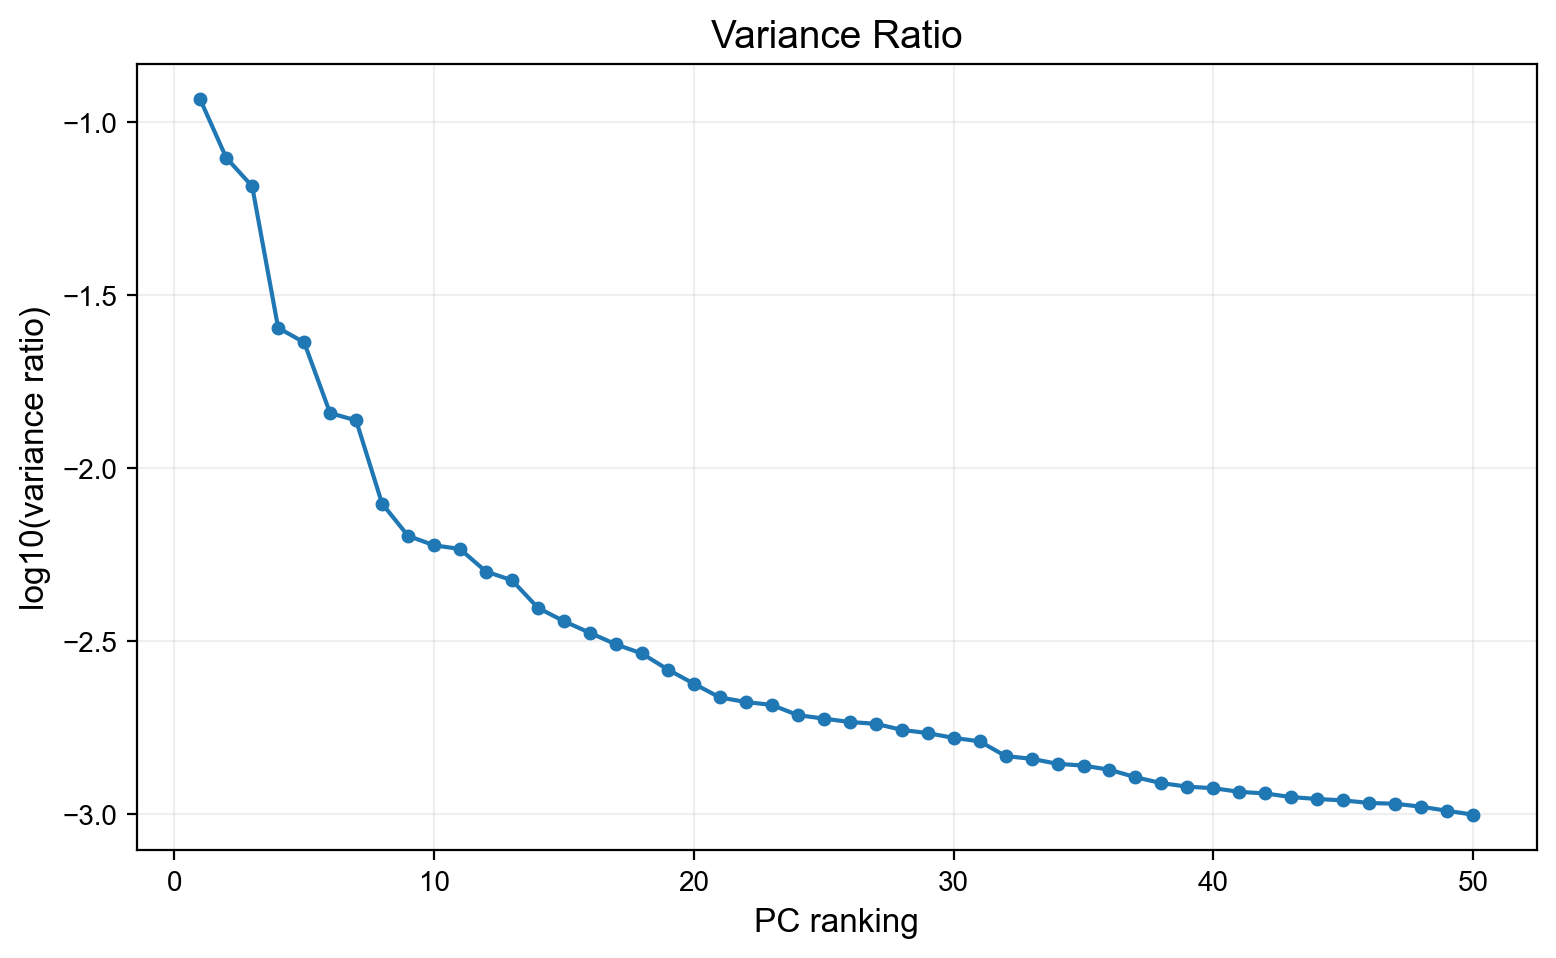

📊 Figure saved: pca_variance_ratio.pdf


In [13]:
# Perform PCA on scaled data
# Compute 50 principal components (default)
sc.tl.pca(adata_filtered, svd_solver='arpack', random_state=42)
print("✅ PCA computed (50 components)")

# Generate PCA elbow plot to visualize variance explained
# This helps determine how many PCs capture meaningful variation

# Original scanpy version (basic plot):
# sc.pl.pca_variance_ratio(adata_filtered, n_pcs=50, log=True, save='.pdf')

# Custom version with improved readability:
import numpy as np
variance_ratio = adata_filtered.uns['pca']['variance_ratio']

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, 51), np.log10(variance_ratio), 'o-', markersize=4, linewidth=1.5)
ax.set_xlabel('PC ranking', fontsize=12)
ax.set_ylabel('log10(variance ratio)', fontsize=12)
ax.set_title('Variance Ratio', fontsize=14)
ax.tick_params(labelsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(DIRS["FIGURES"], "pca_variance_ratio.pdf"), bbox_inches='tight')
plt.show()
print(f"📊 Figure saved: pca_variance_ratio.pdf")

In [14]:
# Compute neighborhood graph
# Use first 30 PCs (capturing majority of variance)
# n_neighbors=15 is a balanced choice for moderate-sized datasets
sc.pp.neighbors(
    adata_filtered,
    n_neighbors=15,
    n_pcs=30,
    random_state=42
)
print("✅ Neighborhood graph computed (15 neighbors, 30 PCs)")

computing neighbors
    using 'X_pca' with n_pcs = 30
    finished (0:00:56)
✅ Neighborhood graph computed (15 neighbors, 30 PCs)


running Leiden clustering
    finished (0:00:14)
✅ Leiden clustering complete
   Number of clusters identified: 23
   Cluster sizes:
leiden
0     8600
1     7611
2     7077
3     5421
4     4752
5     4482
6     3535
7     3118
8     3078
9     3048
10    2984
11    2197
12    1943
13     782
14     740
15     685
16     663
17     579
18     393
19     372
20     356
21     291
22      93
Name: count, dtype: int64


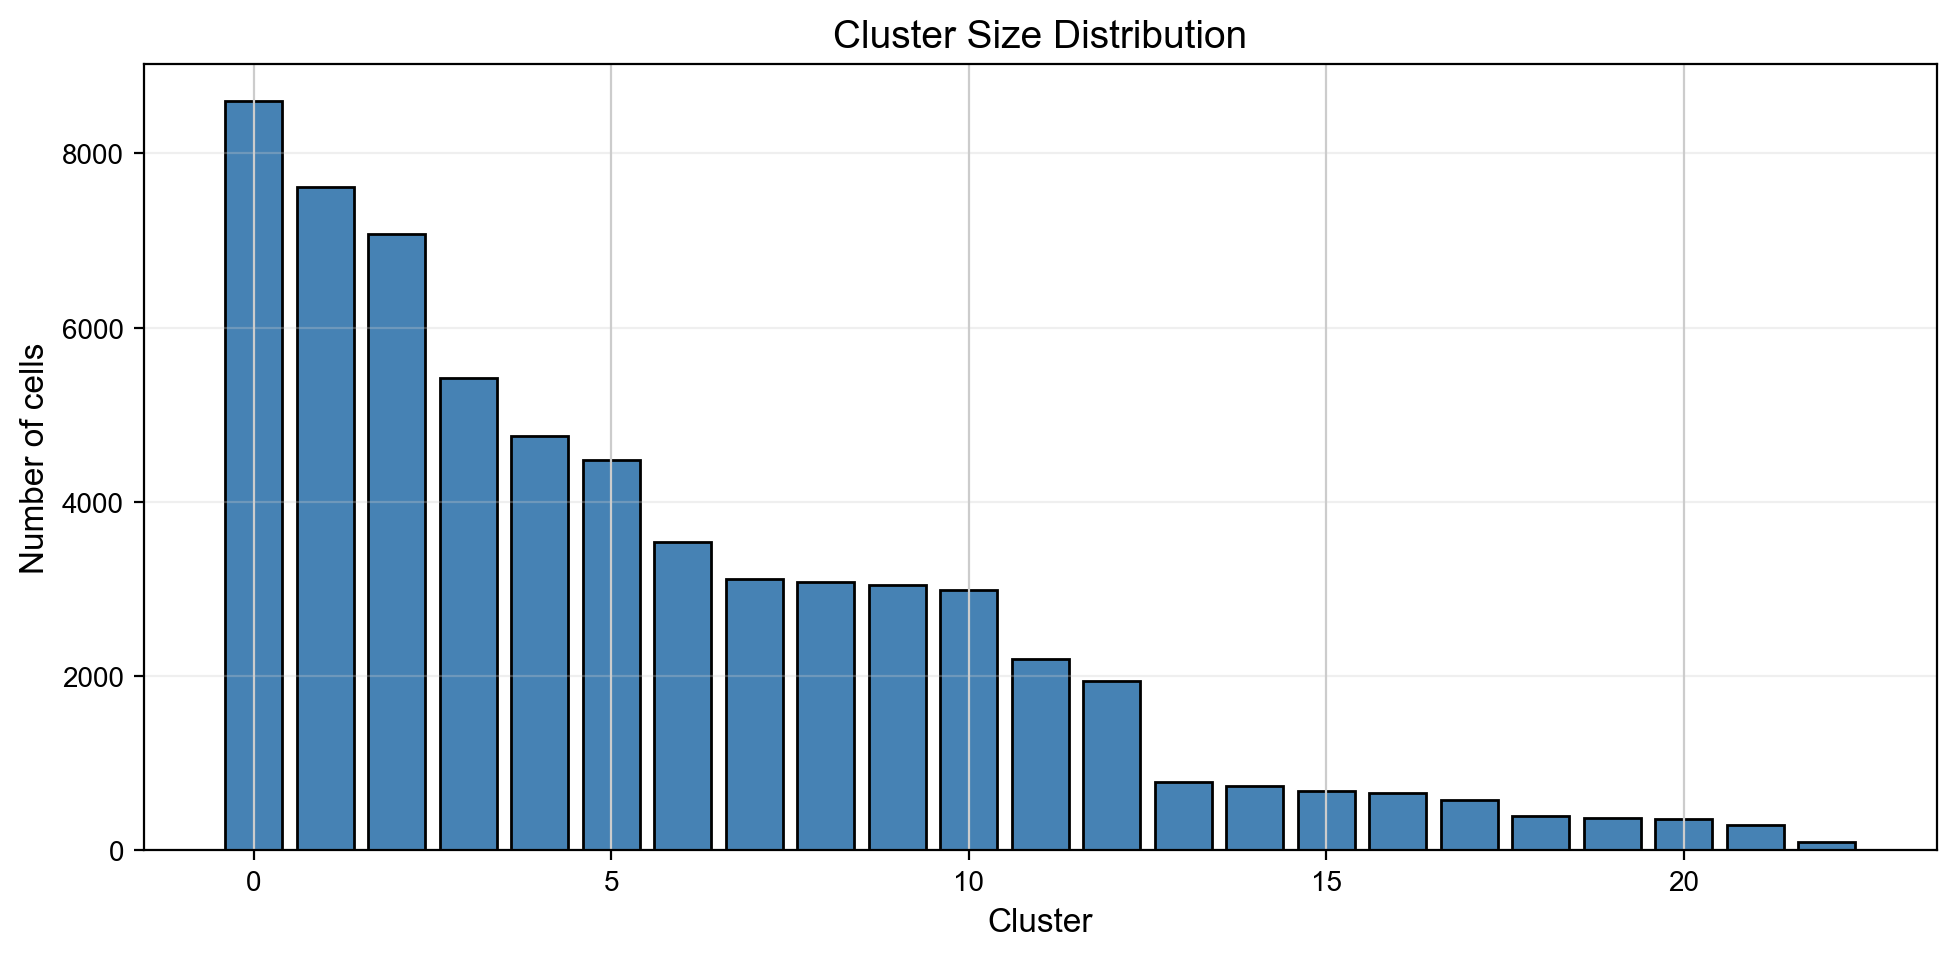

📊 Figure saved: leiden_cluster_sizes.pdf


In [16]:
# Perform Leiden clustering
# Resolution=0.5 provides moderate granularity
# Higher resolution → more clusters; lower resolution → fewer clusters
sc.tl.leiden(
    adata_filtered,
    resolution=0.5,
    random_state=42
)
print(f"✅ Leiden clustering complete")
print(f"   Number of clusters identified: {adata_filtered.obs['leiden'].nunique()}")
print(f"   Cluster sizes:\n{adata_filtered.obs['leiden'].value_counts().sort_index()}")

# Visualize cluster size distribution
fig, ax = plt.subplots(figsize=(10, 5))
cluster_counts = adata_filtered.obs['leiden'].value_counts().sort_index()
ax.bar(cluster_counts.index.astype(int), cluster_counts.values, color='steelblue', edgecolor='black')
ax.set_xlabel('Cluster', fontsize=12)
ax.set_ylabel('Number of cells', fontsize=12)
ax.set_title('Cluster Size Distribution', fontsize=14)
ax.tick_params(labelsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(DIRS["FIGURES"], "leiden_cluster_sizes.pdf"), bbox_inches='tight')
plt.show()
print(f"📊 Figure saved: leiden_cluster_sizes.pdf")

In [17]:
# Compute UMAP embedding for visualization
# UMAP preserves both local and global structure
sc.tl.umap(adata_filtered, random_state=42)
print("✅ UMAP embedding computed")
print(f"   UMAP coordinates stored in adata.obsm['X_umap']")
print(f"   Shape: {adata_filtered.obsm['X_umap'].shape}")
print(f"   Ready for visualization of {adata_filtered.n_obs} cells in 2D space")

computing UMAP
    finished (0:00:48)
✅ UMAP embedding computed
   UMAP coordinates stored in adata.obsm['X_umap']
   Shape: (62800, 2)
   Ready for visualization of 62800 cells in 2D space


### Generate UMAP Visualizations

Create comprehensive UMAP plots colored by:
- Leiden clusters
- Disease diagnosis
- Sex
- Genetic ancestry

These figures will be included in the final report.

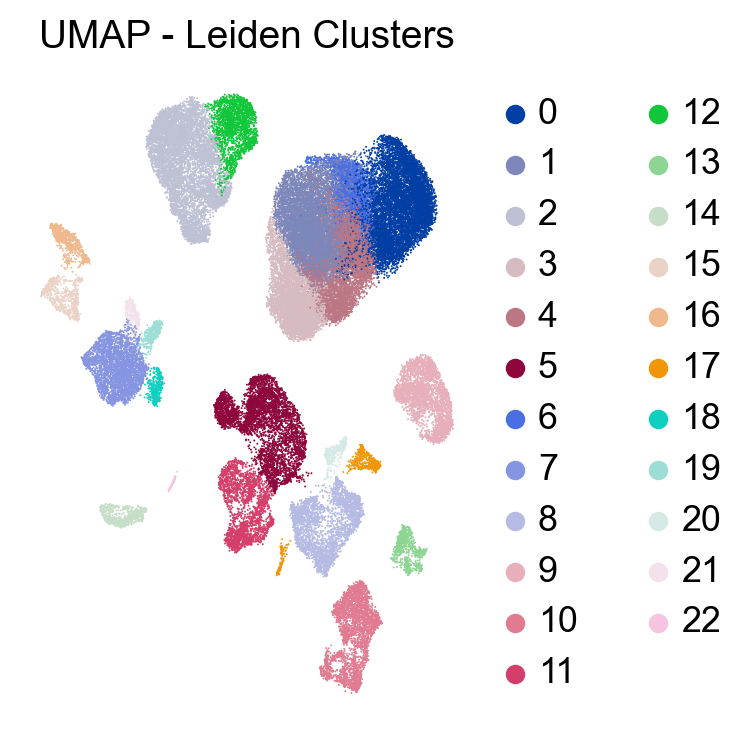

📊 Figure saved: umap_leiden.pdf


In [19]:
# UMAP colored by Leiden clusters
sc.pl.umap(
    adata_filtered,
    color='leiden',
    legend_loc='right margin',
    title='UMAP - Leiden Clusters',
    frameon=False,
    show=False
)
plt.tight_layout()
plt.savefig(os.path.join(DIRS["FIGURES"], "umap_leiden.pdf"), bbox_inches='tight')
plt.show()
print("📊 Figure saved: umap_leiden.pdf")

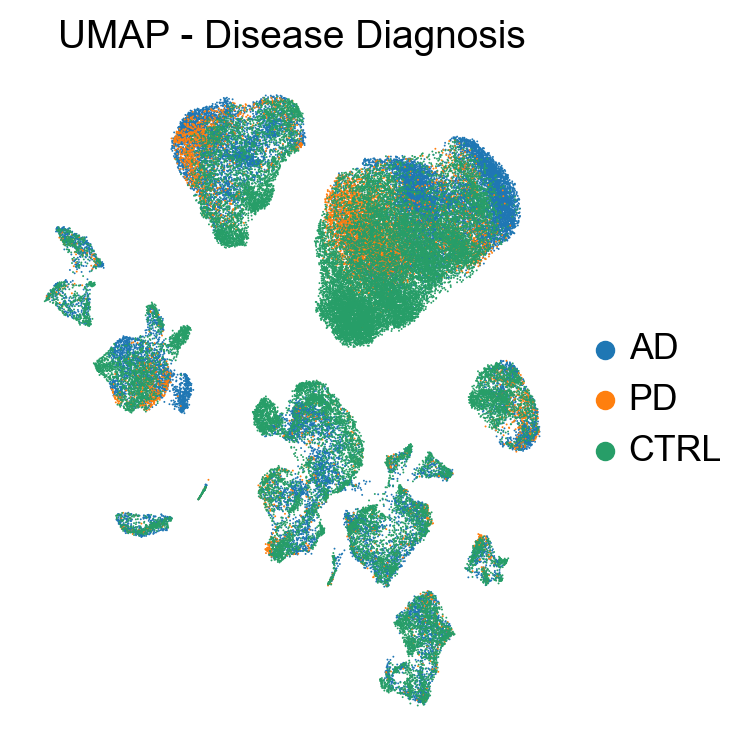

📊 Figure saved: umap_diagnosis.pdf


In [20]:
# UMAP colored by disease diagnosis
sc.pl.umap(
    adata_filtered,
    color='simple_diagnosis',
    legend_loc='right margin',
    title='UMAP - Disease Diagnosis',
    frameon=False,
    show=False
)
plt.tight_layout()
plt.savefig(os.path.join(DIRS["FIGURES"], "umap_diagnosis.pdf"), bbox_inches='tight')
plt.show()
print("📊 Figure saved: umap_diagnosis.pdf")

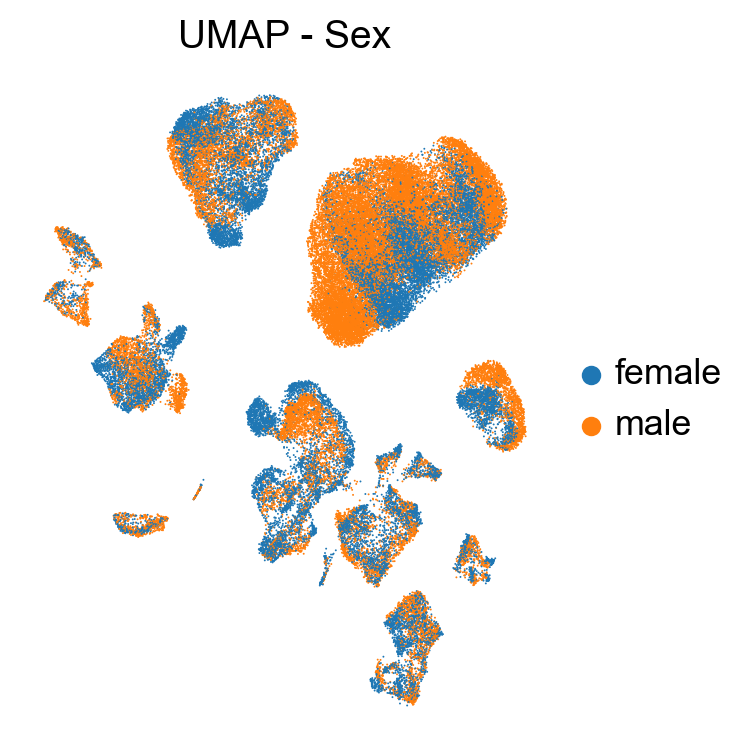

📊 Figure saved: umap_sex.pdf


In [21]:
# UMAP colored by sex
sc.pl.umap(
    adata_filtered,
    color='sex',
    legend_loc='right margin',
    title='UMAP - Sex',
    frameon=False,
    show=False
)
plt.tight_layout()
plt.savefig(os.path.join(DIRS["FIGURES"], "umap_sex.pdf"), bbox_inches='tight')
plt.show()
print("📊 Figure saved: umap_sex.pdf")

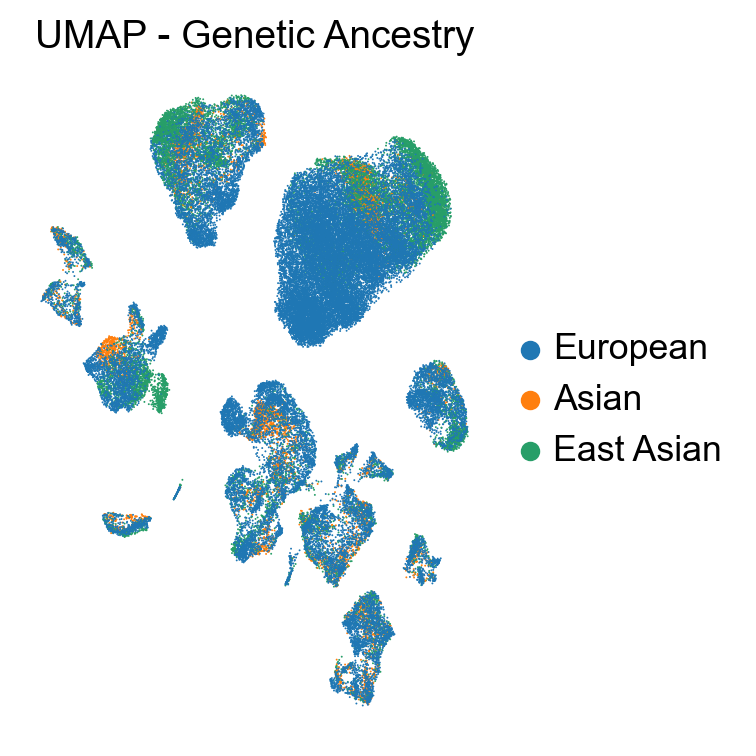

📊 Figure saved: umap_genetic_ancestry.pdf


In [22]:
# UMAP colored by genetic ancestry
sc.pl.umap(
    adata_filtered,
    color='genetic_ancestry',
    legend_loc='right margin',
    title='UMAP - Genetic Ancestry',
    frameon=False,
    show=False
)
plt.tight_layout()
plt.savefig(os.path.join(DIRS["FIGURES"], "umap_genetic_ancestry.pdf"), bbox_inches='tight')
plt.show()
print("📊 Figure saved: umap_genetic_ancestry.pdf")

# **Quality Checks**

### PCA and Technical Variable Assessment

Verify data quality by examining:
1. Distribution of principal components
2. Relationship between UMAP clusters and technical variables (n_counts, n_genes)
3. Potential batch effects (donor-specific patterns)

# **Marker Gene Identification**

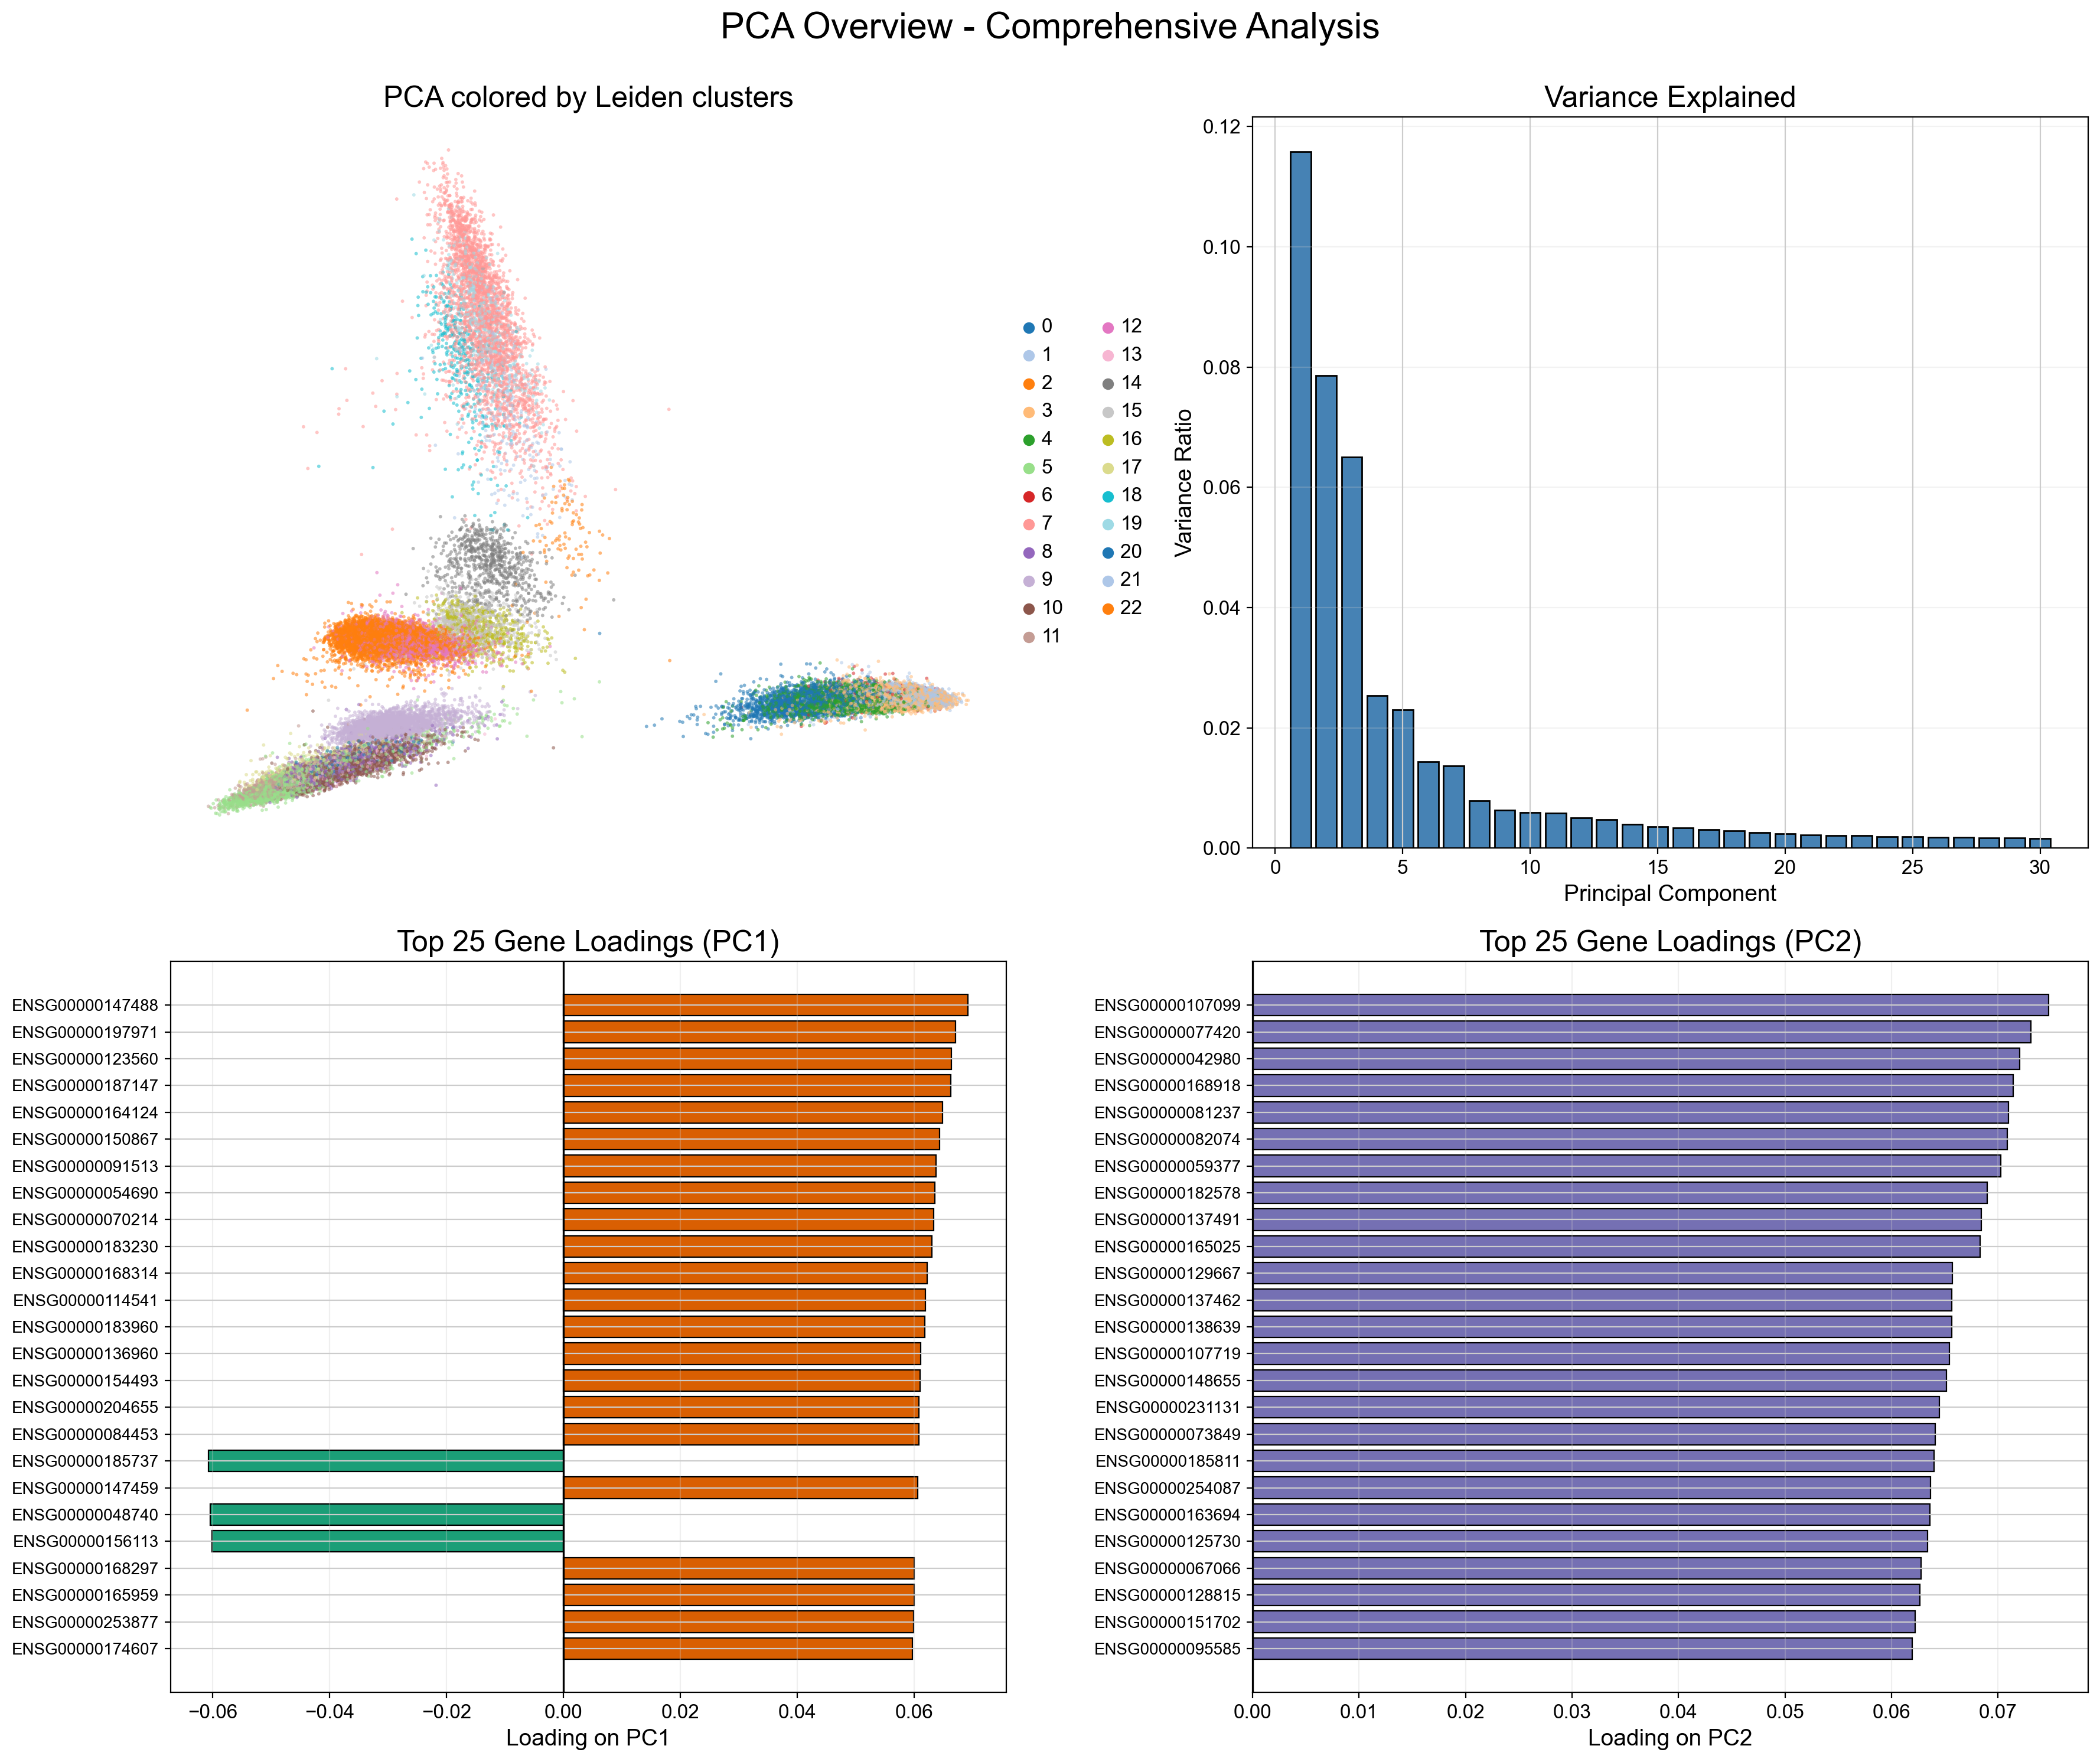

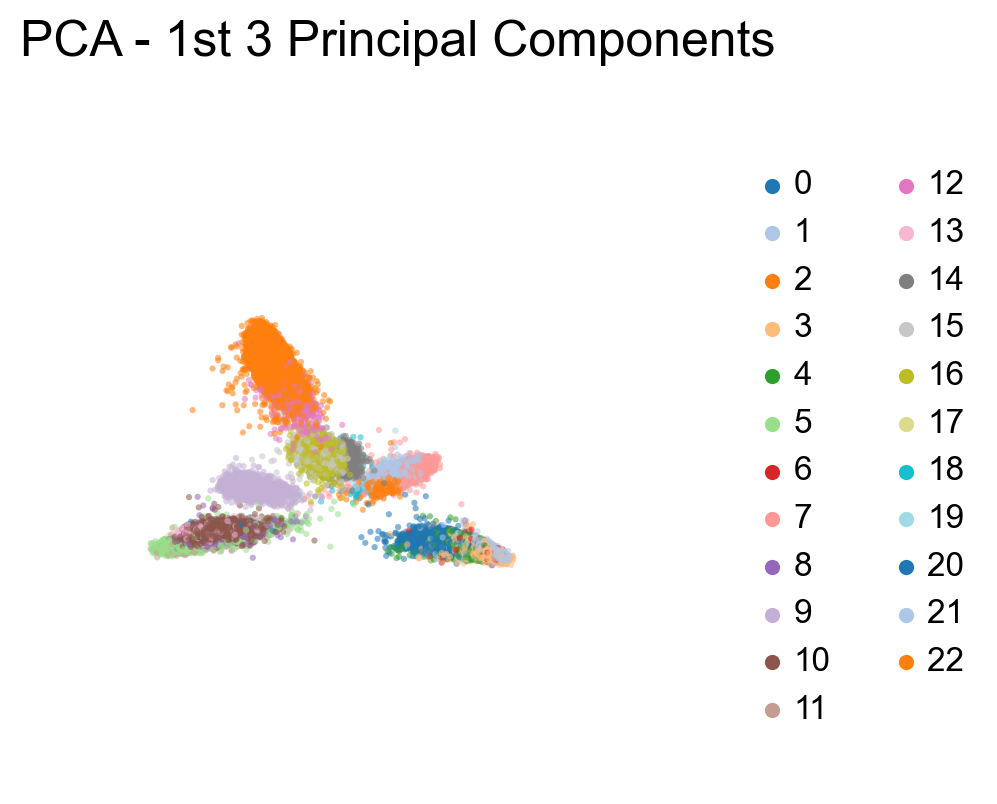

📊 Figure saved: pca_overview.pdf
📊 Figure saved: pca_3d_leiden.pdf


In [52]:
# Visualize PCA components and their loadings
# This comprehensive plot shows how genes contribute to top PCs

# Temporarily increase font sizes for better readability
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 18,
    'axes.labelsize': 14,
    'legend.fontsize': 12,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12
})

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Use a colorblind-friendly palette for consistency
cluster_palette = sns.color_palette("tab20", n_colors=23)

# --- Begin PCA overview figure ---
fig, axes = plt.subplots(2, 2, figsize=(18, 15))

# Top-left: PCA scatter colored by Leiden
sc.pl.pca(
    adata_filtered,
    color='leiden',
    alpha=0.55,
    size=18,
    ax=axes[0, 0],
    show=False,
    frameon=False,
    title='PCA colored by Leiden clusters',
    palette=cluster_palette
)

# Top-right: Variance ratio barplot
variance_ratio = adata_filtered.uns['pca']['variance_ratio'][:30]
axes[0, 1].bar(
    range(1, 31),
    variance_ratio,
    color="steelblue",
    edgecolor="black",
    linewidth=1.0
)
axes[0, 1].set_xlabel('Principal Component')
axes[0, 1].set_ylabel('Variance Ratio')
axes[0, 1].set_title('Variance Explained')
axes[0, 1].grid(axis="y", alpha=0.25)

# Bottom-left: PC1 loadings
pc1_loadings = adata_filtered.varm['PCs'][:, 0]
top_idx_1 = np.argsort(np.abs(pc1_loadings))[-25:]
top_genes_1 = adata_filtered.var_names[top_idx_1]
top_vals_1 = pc1_loadings[top_idx_1]
colors_pc1 = ['#d95f02' if val > 0 else '#1b9e77' for val in top_vals_1]

axes[1, 0].barh(
    range(25),
    top_vals_1,
    color=colors_pc1,
    edgecolor="black",
    linewidth=0.8
)
axes[1, 0].set_yticks(range(25))
axes[1, 0].set_yticklabels(top_genes_1, fontsize=10)
axes[1, 0].set_xlabel("Loading on PC1")
axes[1, 0].set_title("Top 25 Gene Loadings (PC1)")
axes[1, 0].axvline(0, color='black', linewidth=1.2)
axes[1, 0].grid(axis="x", alpha=0.3)

# Bottom-right: PC2 loadings
pc2_loadings = adata_filtered.varm['PCs'][:, 1]
top_idx_2 = np.argsort(np.abs(pc2_loadings))[-25:]
top_genes_2 = adata_filtered.var_names[top_idx_2]
top_vals_2 = pc2_loadings[top_idx_2]
colors_pc2 = ['#7570b3' if val > 0 else '#e7298a' for val in top_vals_2]

axes[1, 1].barh(
    range(25),
    top_vals_2,
    color=colors_pc2,
    edgecolor="black",
    linewidth=0.8
)
axes[1, 1].set_yticks(range(25))
axes[1, 1].set_yticklabels(top_genes_2, fontsize=10)
axes[1, 1].set_xlabel("Loading on PC2")
axes[1, 1].set_title("Top 25 Gene Loadings (PC2)")
axes[1, 1].axvline(0, color='black', linewidth=1.2)
axes[1, 1].grid(axis="x", alpha=0.3)

fig.suptitle("PCA Overview - Comprehensive Analysis", fontsize=22, y=0.995)
plt.tight_layout()
plt.savefig(os.path.join(DIRS["FIGURES"], "pca_overview.pdf"), bbox_inches='tight', dpi=300)
plt.show()
# --- End PCA overview figure ---

# PCA 3D visualization colored by Leiden clusters with improved styling
fig = plt.figure(figsize=(5, 5.5))
ax = fig.add_subplot(111, projection='3d')

sc.pl.pca(
    adata_filtered,
    color='leiden',
    alpha=0.55,
    size=18,
    projection='3d',
    ax=ax,
    show=False,
    frameon=False,
    palette=cluster_palette
)

ax.set_title("PCA - 1st 3 Principal Components", fontsize=18, pad=20)
ax.set_xlabel('PC1', fontsize=14)
ax.set_ylabel('PC2', fontsize=14)
ax.set_zlabel('PC3', fontsize=14)

plt.tight_layout()
plt.savefig(os.path.join(DIRS["FIGURES"], "pca_3d_leiden.pdf"), bbox_inches='tight', dpi=300)
plt.show()

# Reset font sizes
plt.rcParams.update({'font.size': 10, 'axes.titlesize': 11, 'axes.labelsize': 10})

print("📊 Figure saved: pca_overview.pdf")
print("📊 Figure saved: pca_3d_leiden.pdf")


### Differential Expression Analysis

Identify marker genes for each Leiden cluster using the Wilcoxon rank-sum test.

These markers will be used for:
- Biological interpretation of clusters
- Cell type annotation
- Validation of clustering quality

ranking genes
    finished (0:00:28)
✅ Marker gene identification complete (Wilcoxon test)

📋 Top 5 marker genes per cluster:


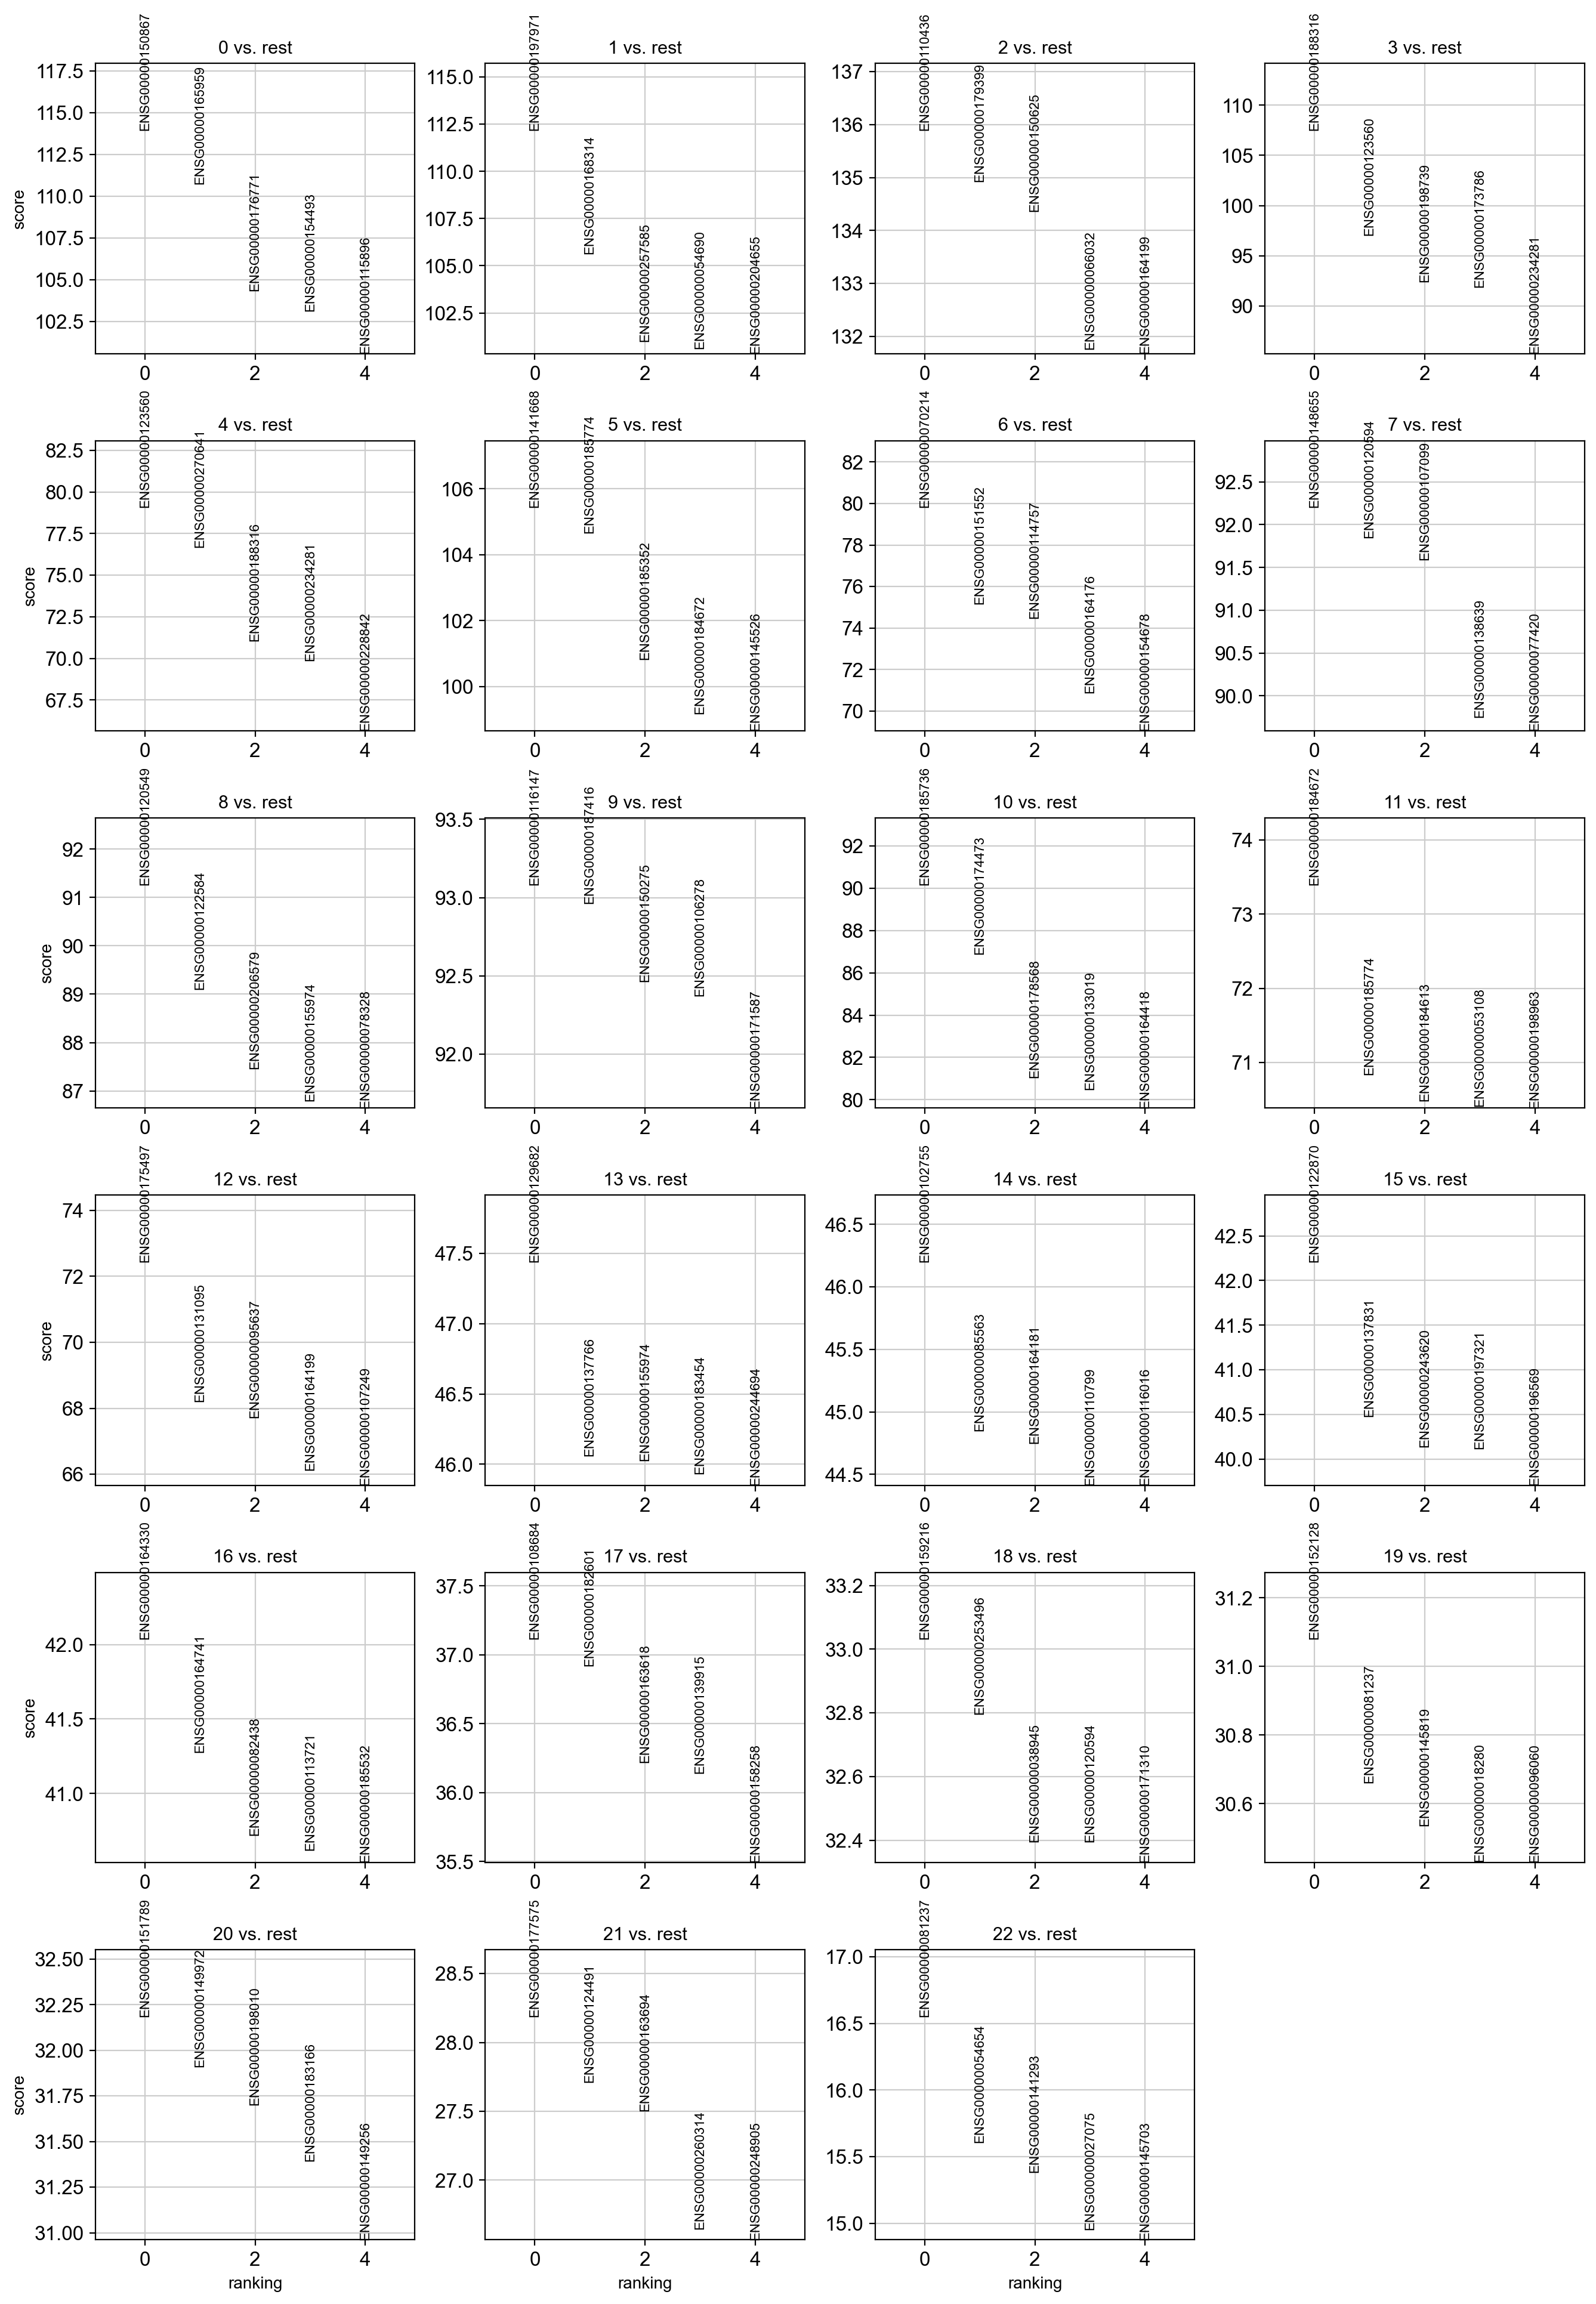

📊 Figure saved: markers_rank_genes.pdf


In [54]:
# Compute marker genes for each cluster
# Use Wilcoxon rank-sum test (non-parametric, robust for scRNA-seq)
# Compare each cluster against all other clusters
sc.tl.rank_genes_groups(
    adata_filtered,
    groupby='leiden',
    method='wilcoxon',
    key_added='rank_genes_leiden'
)
print("✅ Marker gene identification complete (Wilcoxon test)")

# Display top markers for each cluster
print("\n📋 Top 5 marker genes per cluster:")
sc.pl.rank_genes_groups(adata_filtered, n_genes=5, sharey=False, key='rank_genes_leiden', show=False)
plt.savefig(os.path.join(DIRS["FIGURES"], "markers_rank_genes.pdf"), bbox_inches='tight', dpi=300)
plt.show()  # Affiche inline
print("📊 Figure saved: markers_rank_genes.pdf")

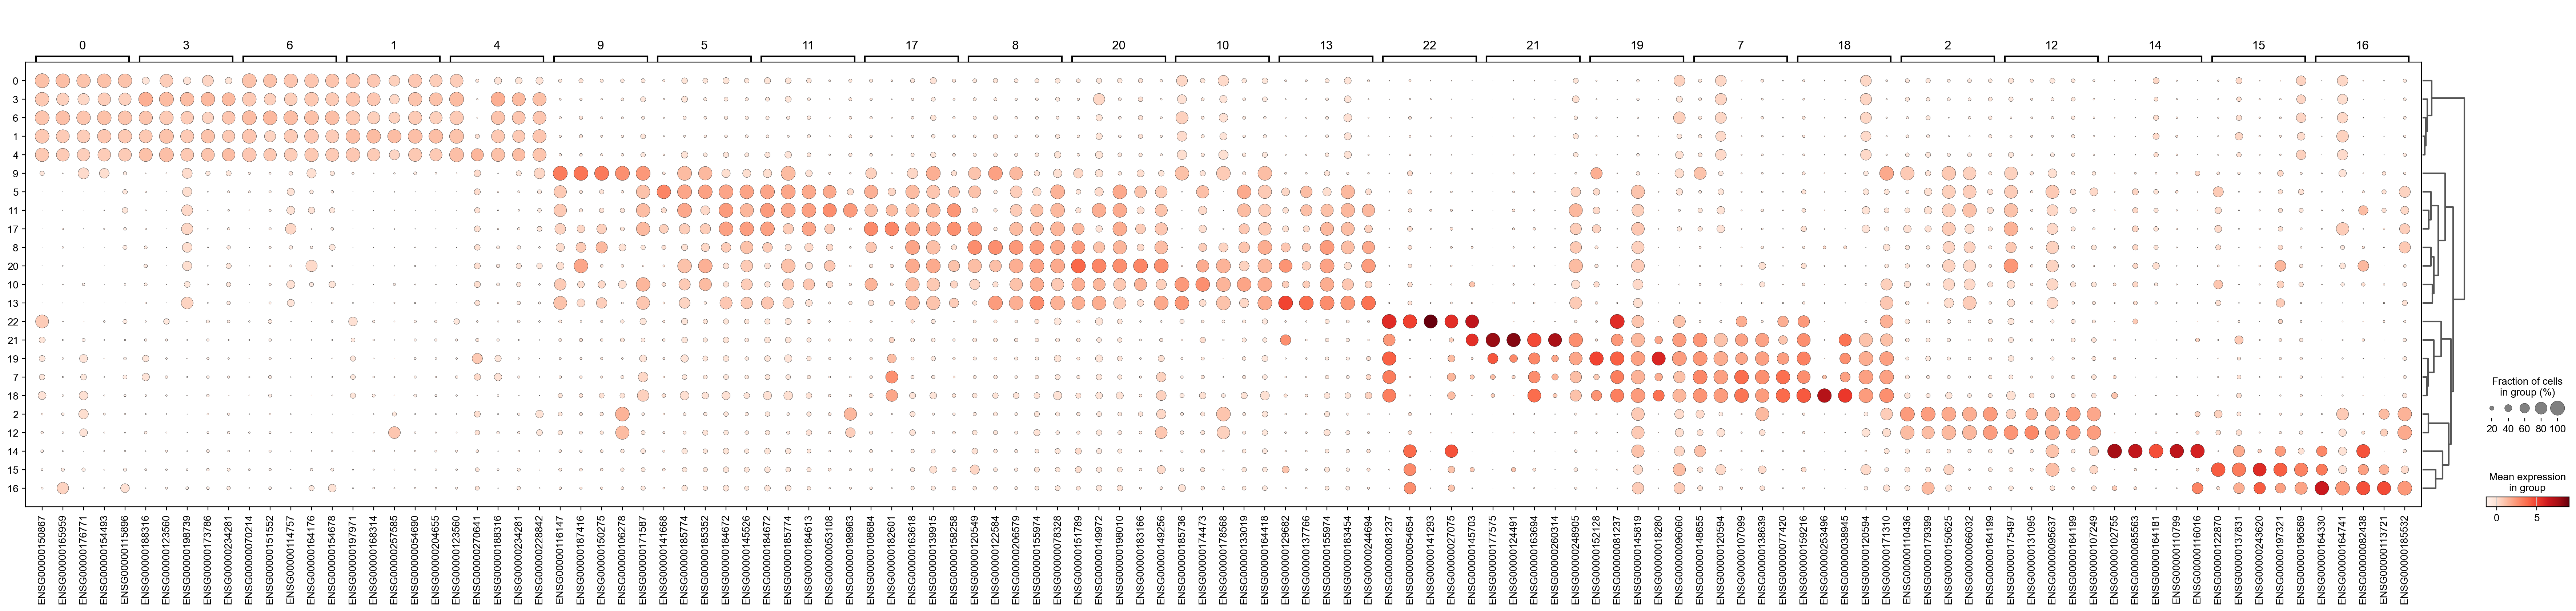

📊 Figure saved: markers_dotplot.pdf


In [56]:
# Generate dotplot of top marker genes
# Shows expression level (color) and percentage of cells expressing (dot size)

# Temporarily increase font sizes
plt.rcParams.update({'font.size': 12, 'axes.titlesize': 14, 'axes.labelsize': 12})

sc.pl.rank_genes_groups_dotplot(
    adata_filtered,
    n_genes=5,
    key='rank_genes_leiden',
    groupby='leiden',
    show=False
)
plt.tight_layout()
plt.savefig(os.path.join(DIRS["FIGURES"], "markers_dotplot.pdf"), bbox_inches='tight', dpi=300)
plt.show()

# Reset font sizes
plt.rcParams.update({'font.size': 10, 'axes.titlesize': 11, 'axes.labelsize': 10})

print("📊 Figure saved: markers_dotplot.pdf")

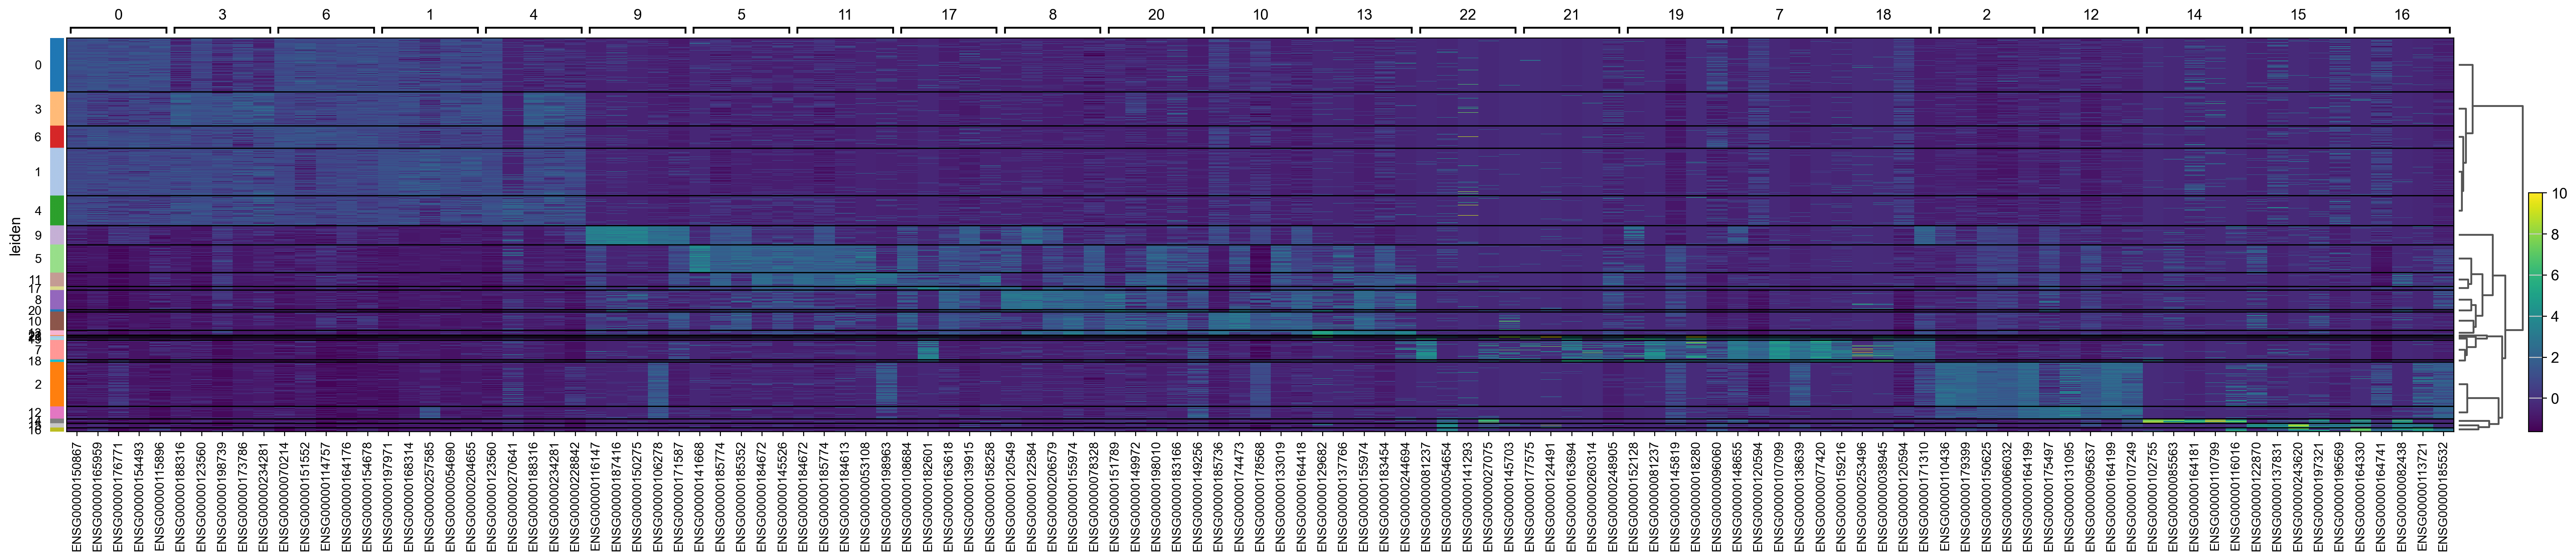

📊 Figure saved: markers_heatmap.pdf


In [58]:
# Generate heatmap of top marker genes
# Shows expression patterns across all cells, grouped by cluster

# Temporarily increase font sizes
plt.rcParams.update({'font.size': 12, 'axes.titlesize': 14, 'axes.labelsize': 12})

sc.pl.rank_genes_groups_heatmap(
    adata_filtered,
    n_genes=5,
    key='rank_genes_leiden',
    groupby='leiden',
    show_gene_labels=True,
    show=False
)
plt.tight_layout()
plt.savefig(os.path.join(DIRS["FIGURES"], "markers_heatmap.pdf"), bbox_inches='tight', dpi=300)
plt.show()

# Reset font sizes
plt.rcParams.update({'font.size': 10, 'axes.titlesize': 11, 'axes.labelsize': 10})

print("📊 Figure saved: markers_heatmap.pdf")

In [59]:
# Export marker genes to CSV for downstream annotation
# Create a table with top markers per cluster
marker_genes = sc.get.rank_genes_groups_df(adata_filtered, group=None, key='rank_genes_leiden')

# Save complete marker table
marker_output_path = os.path.join(DIRS["DATA"], "marker_genes_leiden.csv")
marker_genes.to_csv(marker_output_path, index=False)
print(f"💾 Marker genes saved to: marker_genes_leiden.csv")

# Display summary
print(f"\n📊 Marker gene statistics:")
print(f"   Total markers identified: {len(marker_genes):,}")
print(f"   Clusters analyzed: {marker_genes['group'].nunique()}")
print(f"\n📋 Top 3 markers per cluster:")
for cluster in sorted(marker_genes['group'].unique()):
    top_markers = marker_genes[marker_genes['group'] == cluster].head(3)['names'].tolist()
    print(f"   Cluster {cluster}: {', '.join(top_markers)}")

💾 Marker genes saved to: marker_genes_leiden.csv

📊 Marker gene statistics:
   Total markers identified: 46,000
   Clusters analyzed: 23

📋 Top 3 markers per cluster:
   Cluster 0: ENSG00000150867, ENSG00000165959, ENSG00000176771
   Cluster 1: ENSG00000197971, ENSG00000168314, ENSG00000257585
   Cluster 10: ENSG00000185736, ENSG00000174473, ENSG00000178568
   Cluster 11: ENSG00000184672, ENSG00000185774, ENSG00000184613
   Cluster 12: ENSG00000175497, ENSG00000131095, ENSG00000095637
   Cluster 13: ENSG00000129682, ENSG00000137766, ENSG00000155974
   Cluster 14: ENSG00000102755, ENSG00000085563, ENSG00000164181
   Cluster 15: ENSG00000122870, ENSG00000137831, ENSG00000243620
   Cluster 16: ENSG00000164330, ENSG00000164741, ENSG00000082438
   Cluster 17: ENSG00000108684, ENSG00000182601, ENSG00000163618
   Cluster 18: ENSG00000159216, ENSG00000253496, ENSG00000038945
   Cluster 19: ENSG00000152128, ENSG00000081237, ENSG00000145819
   Cluster 2: ENSG00000110436, ENSG00000179399, ENSG000

# **Save Processed Object**

### Export Processed Dataset

Save the fully processed AnnData object (`adata_pp.h5ad`) containing:
- Normalized and scaled expression data
- Raw counts (in `layers["counts"]`)
- PCA, UMAP embeddings
- Leiden clusters
- Marker gene results

This object will be used for:
- Cluster annotation
- Pseudobulk analysis (in `translation_to_R.ipynb`)
- Further downstream analyses

In [60]:
# Save the processed AnnData object
output_path = os.path.join(DIRS["DATA"], "adata_pp.h5ad")
adata_filtered.write(output_path, compression="gzip")

print("\n" + "="*60)
print("✅ PIPELINE COMPLETE")
print("="*60)
print(f"\n💾 Processed dataset saved to: adata_pp.h5ad")
print(f"   File size: {os.path.getsize(output_path) / (1024**2):.2f} MB")
print(f"\n📊 Final dataset summary:")
print(f"   Cells: {adata_filtered.shape[0]:,}")
print(f"   Genes (HVGs): {adata_filtered.shape[1]:,}")
print(f"   Clusters: {adata_filtered.obs['leiden'].nunique()}")
print(f"   Disease groups: {adata_filtered.obs['simple_diagnosis'].unique().tolist()}")
print(f"\n📁 Figures saved to: {DIRS['FIGURES']}")
print(f"   Total figures generated: {len([f for f in os.listdir(DIRS['FIGURES']) if f.endswith('.pdf')])}")
print(f"\n🔬 Next steps:")
print(f"   1. Review UMAP plots and marker genes for cluster annotation")
print(f"   2. Use adata_pp.h5ad for pseudobulk analysis in translation_to_R.ipynb")
print(f"   3. Perform differential expression analysis between disease groups")
print("\n" + "="*60)


✅ PIPELINE COMPLETE

💾 Processed dataset saved to: adata_pp.h5ad
   File size: 275.73 MB

📊 Final dataset summary:
   Cells: 62,800
   Genes (HVGs): 2,000
   Clusters: 23
   Disease groups: ['AD', 'PD', 'CTRL']

📁 Figures saved to: C:/Z/AIDA_transcriptomics_project/transcriptomics-code\figures\single_cell_pipeline
   Total figures generated: 15

🔬 Next steps:
   1. Review UMAP plots and marker genes for cluster annotation
   2. Use adata_pp.h5ad for pseudobulk analysis in translation_to_R.ipynb
   3. Perform differential expression analysis between disease groups



---

### Pipeline Summary

**Input:** `adata_filtered.h5ad` (QC-filtered dataset)

**Processing steps:**
1. ✅ Normalization (10,000 counts per cell)
2. ✅ Log-transformation
3. ✅ HVG selection (2,000 genes)
4. ✅ Scaling (max_value=10)
5. ✅ PCA (50 components)
6. ✅ Neighborhood graph (15 neighbors, 30 PCs)
7. ✅ Leiden clustering (resolution=0.5)
8. ✅ UMAP embedding
9. ✅ Marker gene identification (Wilcoxon test)

**Output:** 
- `adata_pp.h5ad` (processed dataset)
- PDF figures for report
- `marker_genes_leiden.csv` (marker table)

**Note:** No batch correction or integration was performed due to small cohort size (particularly PD with only 3 donors).

# **Figure 2 : UMAP Multi-Panel (4 colorations)**

Consolidation des visualisations UMAP en un panneau 2×2 pour le rapport :
- **Panel A** : Clusters Leiden
- **Panel B** : Diagnostic (AD/PD/CTRL)
- **Panel C** : Sexe
- **Panel D** : Ascendance génétique

**Format** : PNG haute résolution (300 dpi) pour insertion dans Word.

In [ ]:
# --- FIGURE 2 : UMAP Multi-Panel (4 colorations) ---
print("="*70)
print("📊 Génération Figure 2 : UMAP Multi-Panel")
print("="*70)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Panel A : Leiden Clusters
sc.pl.umap(
    adata_filtered,
    color="leiden",
    ax=axes[0, 0],
    show=False,
    title="A. Leiden Clusters",
    legend_loc="on data",
    size=20,
    frameon=False
)

# Panel B : Diagnostic (simple_diagnosis)
sc.pl.umap(
    adata_filtered,
    color="simple_diagnosis",
    ax=axes[0, 1],
    show=False,
    title="B. Diagnosis (AD/PD/CTRL)",
    palette=["#2E7D32", "#F57C00", "#C62828"],
    size=20,
    frameon=False
)

# Panel C : Sexe
sc.pl.umap(
    adata_filtered,
    color="sex",
    ax=axes[1, 0],
    show=False,
    title="C. Sex",
    size=20,
    frameon=False
)

# Panel D : Ascendance génétique
sc.pl.umap(
    adata_filtered,
    color="genetic_ancestry",
    ax=axes[1, 1],
    show=False,
    title="D. Genetic Ancestry",
    size=20,
    frameon=False
)

plt.tight_layout()

# Sauvegarde en PNG haute résolution
fig2_path = os.path.join(PROJECT_ROOT, "figures", "Fig2_UMAP_MultiPanel.png")
plt.savefig(fig2_path, dpi=300, bbox_inches="tight")
print(f"✅ Figure 2 sauvegardée : {fig2_path}")
plt.show()
print("="*70)

# **Figure 2 : UMAP Multi-Panel (4 colorations)**

Consolidation des visualisations UMAP en un panneau 2x2 pour le rapport :
- **Panel A** : Clusters Leiden
- **Panel B** : Diagnostic (AD/PD/CTRL)
- **Panel C** : Sexe
- **Panel D** : Ascendance genetique

**Format** : PNG haute resolution (300 dpi) pour insertion dans Word.

In [ ]:
# --- FIGURE 2 : UMAP Multi-Panel (4 colorations) ---
print("="*70)
print("Generation Figure 2 : UMAP Multi-Panel")
print("="*70)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Panel A : Leiden Clusters
sc.pl.umap(
    adata_filtered,
    color="leiden",
    ax=axes[0, 0],
    show=False,
    title="A. Leiden Clusters",
    legend_loc="on data",
    size=20,
    frameon=False
)

# Panel B : Diagnostic (simple_diagnosis)
sc.pl.umap(
    adata_filtered,
    color="simple_diagnosis",
    ax=axes[0, 1],
    show=False,
    title="B. Diagnosis (AD/PD/CTRL)",
    palette=["#2E7D32", "#F57C00", "#C62828"],
    size=20,
    frameon=False
)

# Panel C : Sexe
sc.pl.umap(
    adata_filtered,
    color="sex",
    ax=axes[1, 0],
    show=False,
    title="C. Sex",
    size=20,
    frameon=False
)

# Panel D : Ascendance genetique
sc.pl.umap(
    adata_filtered,
    color="genetic_ancestry",
    ax=axes[1, 1],
    show=False,
    title="D. Genetic Ancestry",
    size=20,
    frameon=False
)

plt.tight_layout()

# Sauvegarde en PNG haute resolution
fig2_path = os.path.join(PROJECT_ROOT, "figures", "Fig2_UMAP_MultiPanel.png")
plt.savefig(fig2_path, dpi=300, bbox_inches="tight")
print(f"Figure 2 sauvegardee : {fig2_path}")
plt.show()
print("="*70)

# **Figure 3 : Dot Plot (Top Marqueurs par Cluster Leiden)**

Visualisation des 5 meilleurs marqueurs pour chaque cluster Leiden.

**Note** : Les genes sont au format ENSEMBL IDs. Cette figure utilise les marqueurs calcules par `sc.tl.rank_genes_groups()` et regroupe par cluster Leiden pour valider la qualite du clustering.

**Format** : PNG haute resolution (300 dpi) pour insertion dans Word.

In [ ]:
# --- FIGURE 3 : Dot Plot (Top Marqueurs par Cluster Leiden) ---
print("="*70)
print("Generation Figure 3 : Dot Plot Markers")
print("="*70)

# Augmenter temporairement la taille des polices pour meilleure lisibilite
plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12
})

# Generation du Dot Plot avec top 5 marqueurs par cluster
sc.pl.rank_genes_groups_dotplot(
    adata_filtered,
    n_genes=5,
    key="rank_genes_leiden",
    groupby="leiden",
    show=False
)

plt.tight_layout()

# Sauvegarde en PNG haute resolution
fig3_path = os.path.join(PROJECT_ROOT, "figures", "Fig3_DotPlot_Markers.png")
plt.savefig(fig3_path, dpi=300, bbox_inches="tight")
print(f"Figure 3 sauvegardee : {fig3_path}")
plt.show()

# Reinitialiser les polices
plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10
})

print("="*70)